# Random Forest Classification on Bank Marketing Dataset

## Introduction
Machine learning can be used to analyze real-world customer data and predict future outcomes. In this study, the Bank Marketing dataset is used to build a Random Forest classification model that predicts whether a customer will subscribe to a term deposit. Since the dataset contains both numerical and categorical attributes, proper preprocessing and evaluation are important before training the model.

## Problem Description
This study addresses the problem of predicting whether a bank customer will subscribe to a term deposit based on demographic and campaign-related information. This is a binary classification problem in machine learning, where the target variable has two possible outcomes: `yes` or `no`.

## Objective
The main objective of this task is to develop a Random Forest classification model to predict whether a customer will subscribe to a term deposit based on bank marketing data. The model will be evaluated using suitable performance metrics such as accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

## Load Dataset

In [2]:
df = pd.read_csv("bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

## Dataset Size and Target Distribution

In [4]:
print("Dataset shape:", df.shape)
print("\nTarget Distribution:")
print(df['y'].value_counts())
print("\nTarget Distribution (Percentage):")
print(df['y'].value_counts(normalize=True) * 100)

Dataset shape: (45211, 17)

Target Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Target Distribution (Percentage):
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


The dataset contains multiple customer records with a binary target variable `y`, which indicates whether the customer subscribed to a term deposit. The distribution of the target classes is checked to understand whether the dataset is balanced or imbalanced.

### Additional Exploration

In [20]:
# Check data types and missing values
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary of Numerical Features:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Missing Values:
age          0
job          0
marital      0
education    0
default      0
ba

## Feature and Target Separation

In [5]:
X = df.drop("y", axis=1)
y = df["y"].map({"no": 0, "yes": 1})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (45211, 16)
Target shape: (45211,)


The input variables were separated into `X`, while the target variable `y` was converted into binary format where `no = 0` and `yes = 1`.

## Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (36168, 16)
X_test : (9043, 16)
y_train: (36168,)
y_test : (9043,)


The dataset was split into training and testing sets using an 80:20 ratio. Stratified sampling was used to preserve the target class distribution in both training and testing subsets.

## Identify Categorical and Numerical Features
Since the dataset contains both categorical and numerical attributes, they were identified separately. This is important because each type requires different preprocessing steps before model training.

In [7]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical Features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## Data Preprocessing and Model Pipeline
A preprocessing pipeline was created to handle numerical and categorical features separately. Numerical features were imputed using the median strategy, while categorical features were imputed using the most frequent value and then transformed using one-hot encoding. This preprocessing step was combined with the Random Forest classifier into a single pipeline.

In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

## Model Training
The Random Forest model was trained using the training dataset through the preprocessing pipeline. This ensures that preprocessing and model fitting are performed consistently.

In [9]:
model_pipeline.fit(X_train, y_train)
print("Model training completed successfully.")

Model training completed successfully.


## Model Prediction
After training, the model was used to predict the target labels for the unseen test dataset. Probability scores were also generated for ROC-AUC evaluation.

In [10]:
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

print("First 10 Predictions:", y_pred[:10])

First 10 Predictions: [0 0 0 0 0 0 0 1 0 0]


## Model Evaluation
The model was evaluated using accuracy, confusion matrix, precision, recall, and F1-score. Since the dataset is imbalanced, multiple metrics were considered instead of relying only on accuracy.

In [11]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Accuracy: 0.9043459029083268

Confusion Matrix:
 [[7758  227]
 [ 638  420]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.40      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



## ROC-AUC Evaluation
ROC-AUC was used to evaluate the model’s ability to distinguish between the two target classes across different classification thresholds. A higher ROC-AUC score indicates better classification performance.

In [12]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9264332461740055


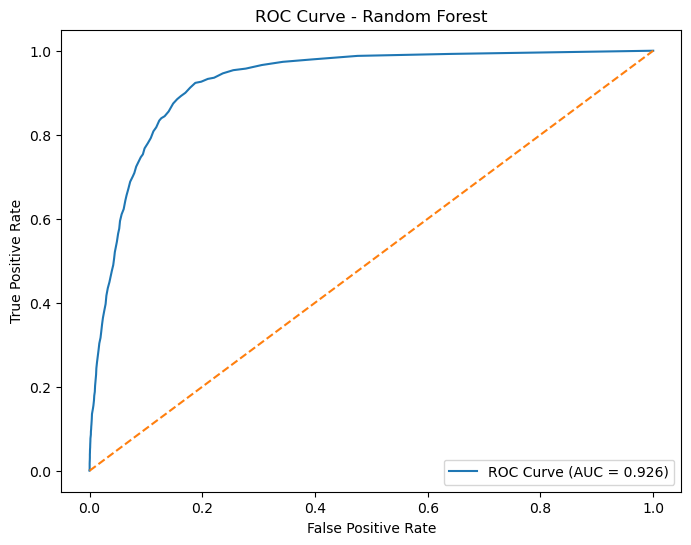

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

## Hyperparameter Tuning / Improved Model
To improve the Random Forest model, hyperparameter tuning was performed using GridSearchCV. Different combinations of parameters such as number of trees, depth, minimum samples split, and class weights were tested to identify the best-performing configuration.

In [14]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 15, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
    "classifier__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

Best Parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


In [15]:
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("Improved Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nImproved Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nImproved Model Classification Report:\n", classification_report(y_test, y_pred_best))
print("Improved Model ROC-AUC:", roc_auc_score(y_test, y_prob_best))

Improved Model Accuracy: 0.8761472962512441

Improved Model Confusion Matrix:
 [[7090  895]
 [ 225  833]]

Improved Model Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93      7985
           1       0.48      0.79      0.60      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.84      0.76      9043
weighted avg       0.91      0.88      0.89      9043

Improved Model ROC-AUC: 0.9245464972721774


## Visualizations
### Target distribution

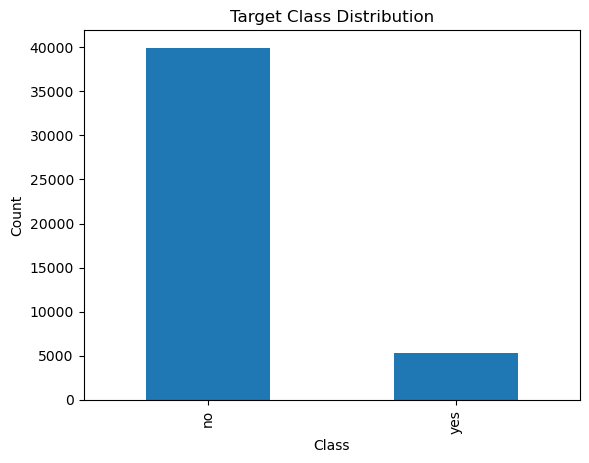

In [17]:
df["y"].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Confusion matrix

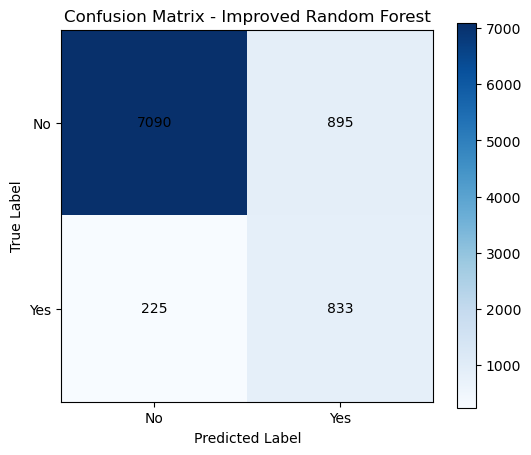

In [18]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
plt.imshow(cm_best, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix - Improved Random Forest")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['No', 'Yes'])
plt.yticks(tick_marks, ['No', 'Yes'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_best.shape[0]):
    for j in range(cm_best.shape[1]):
        plt.text(j, i, format(cm_best[i, j], 'd'),
                 ha="center", va="center", color="black")

plt.show()

### Feature importance

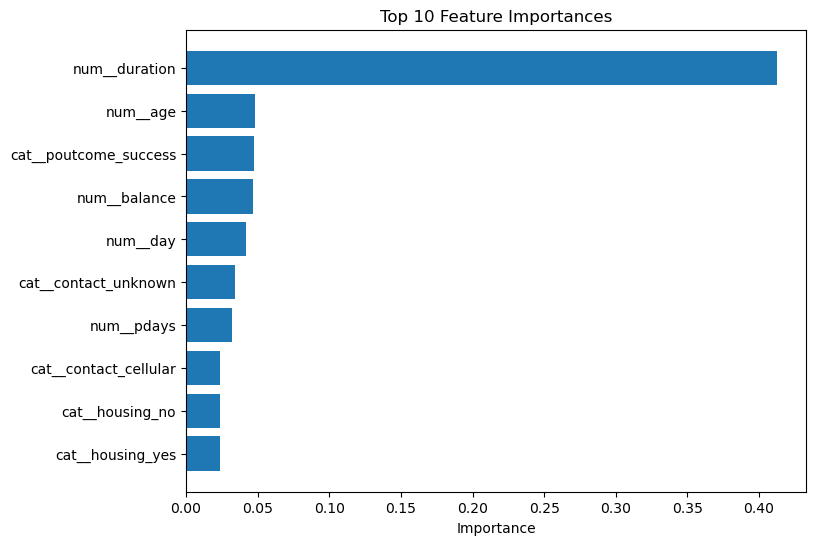

In [19]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top_10_features = feature_importance_df.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_10_features["Feature"], top_10_features["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

## Interpretation of Visualizations
The target distribution chart shows that the dataset is imbalanced, with more `no` instances than `yes` instances.  
The confusion matrix helps identify how many samples were correctly and incorrectly classified.  
The ROC curve shows the ability of the model to separate the two classes across different thresholds.  
The feature importance chart highlights the most influential attributes used by the Random Forest model during prediction.

## Important Observation
One important observation is that the dataset is imbalanced, which means that high accuracy alone does not guarantee strong performance for the minority class. Therefore, recall, F1-score, and ROC-AUC must also be considered. Another observation is that some features contribute much more strongly to prediction than others, as shown in the feature importance chart.

## Conclusion
The Random Forest classification model was successfully developed for the Bank Marketing dataset. Proper preprocessing was applied using a machine learning pipeline, and the model was evaluated using several suitable metrics. The improved model produced better results after hyperparameter tuning. Overall, Random Forest performed well for this classification task, although class imbalance remained an important challenge. Future improvements could include resampling methods, more advanced tuning, and comparison with other algorithms.